In [3]:
from pathlib import Path
from rosbags.typesys import get_typestore, Stores, get_types_from_msg
from rosbags.rosbag2 import Reader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/home/adrian/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [9]:
# --- Configuration ---
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path().resolve()

# Bag recorded while rotating the IMU in a circle (for magnetometer calibration)
BAG_PATH_circle = NOTEBOOK_DIR.parents[1] / "src/data/data_going_in_circles"
# Bag recorded while driving
BAG_PATH_drive  = NOTEBOOK_DIR.parents[1] / "src/data/data_going_in_circles"

IMU_TOPIC = "/imu"
GPS_TOPIC = "/gps"

IMU_MSG_PATH = "/home/adrian/EECE5554/LAB4/src/imu_msg/msg/IMUmsg.msg"
IMU_MSG_TYPE = "imu_msg/msg/IMUmsg"

GPS_MSG_PATH = "/home/adrian/EECE5554/LAB4/src/gps_driver_msgs/msg/GpsMsg.msg"
GPS_MSG_TYPE = "gps_driver_msgs/msg/GpsMsg"

In [10]:
typestore = get_typestore(Stores.ROS2_HUMBLE)

def register_msg_file(typestore, msg_path: str, full_type_name: str):
    msg_text = Path(msg_path).read_text()
    add_types = get_types_from_msg(msg_text, full_type_name)
    typestore.register(add_types)

register_msg_file(typestore, IMU_MSG_PATH, IMU_MSG_TYPE)
register_msg_file(typestore, GPS_MSG_PATH, GPS_MSG_TYPE)

In [11]:
def quaternion_to_euler(w, x, y, z):
    """Convert quaternion to Euler angles (roll, pitch, yaw) in degrees."""
    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    sinp = 2 * (w * y - z * x)
    sinp = np.clip(sinp, -1.0, 1.0)
    pitch = np.arcsin(sinp)

    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    return np.degrees(roll), np.degrees(pitch), np.degrees(yaw)


def bag_to_df_imu(bag_path, typestore, topic: str = "/imu") -> pd.DataFrame:
    rows = []
    with Reader(bag_path) as reader:
        for connection, timestamp, rawdata in reader.messages():
            if connection.topic != topic:
                continue
            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)

            qx = float(msg.imu.orientation.x)
            qy = float(msg.imu.orientation.y)
            qz = float(msg.imu.orientation.z)
            qw = float(msg.imu.orientation.w)
            roll, pitch, yaw = quaternion_to_euler(qw, qx, qy, qz)

            rows.append({
                "bag_time_ns": int(timestamp),
                "gyro_x":    float(msg.imu.angular_velocity.x),
                "gyro_y":    float(msg.imu.angular_velocity.y),
                "gyro_z":    float(msg.imu.angular_velocity.z),
                "accel_x":   float(msg.imu.linear_acceleration.x),
                "accel_y":   float(msg.imu.linear_acceleration.y),
                "accel_z":   float(msg.imu.linear_acceleration.z),
                "mag_x":     float(msg.mag_field.magnetic_field.x),
                "mag_y":     float(msg.mag_field.magnetic_field.y),
                "mag_z":     float(msg.mag_field.magnetic_field.z),
                "roll_deg":  roll,
                "pitch_deg": pitch,
                "yaw_deg":   yaw,
            })

    df = pd.DataFrame(rows)
    df["time_s"]    = (df["bag_time_ns"] - df["bag_time_ns"].iloc[0]) * 1e-9
    df["timestamp"] = df["time_s"]   # alias used in analysis cells
    df["imu_yaw"]   = df["yaw_deg"]  # alias used in analysis cells
    return df


def bag_to_df_gps(bag_path, typestore, topic: str = "/gps") -> pd.DataFrame:
    rows = []
    with Reader(bag_path) as reader:
        for connection, timestamp, rawdata in reader.messages():
            if connection.topic != topic:
                continue
            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)
            rows.append({
                "bag_time_ns":   int(timestamp),
                "latitude":      float(msg.latitude),
                "longitude":     float(msg.longitude),
                "altitude":      float(msg.altitude),
                "utm_easting":   float(msg.utm_easting),
                "utm_northing":  float(msg.utm_northing),
                "hdop":          float(msg.hdop),
                "utc":           str(msg.utc),
                "zone":          str(msg.zone),
            })
    df = pd.DataFrame(rows)
    df["time_s"] = (df["bag_time_ns"] - df["bag_time_ns"].iloc[0]) * 1e-9
    return df

## Load Bags into DataFrames

In [12]:
df_circle = bag_to_df_imu(BAG_PATH_circle, typestore, IMU_TOPIC)
df_drive  = bag_to_df_imu(BAG_PATH_drive,  typestore, IMU_TOPIC)
df_gps    = bag_to_df_gps(BAG_PATH_drive,  typestore, GPS_TOPIC)

print(f"Circle bag: {len(df_circle)} IMU samples, {df_circle['time_s'].iloc[-1]:.1f} s")
print(f"Drive bag:  {len(df_drive)}  IMU samples, {df_drive['time_s'].iloc[-1]:.1f} s")
print(f"Drive bag:  {len(df_gps)}   GPS samples")

Circle bag: 222 IMU samples, 5017.2 s
Drive bag:  222  IMU samples, 5017.2 s
Drive bag:  221   GPS samples


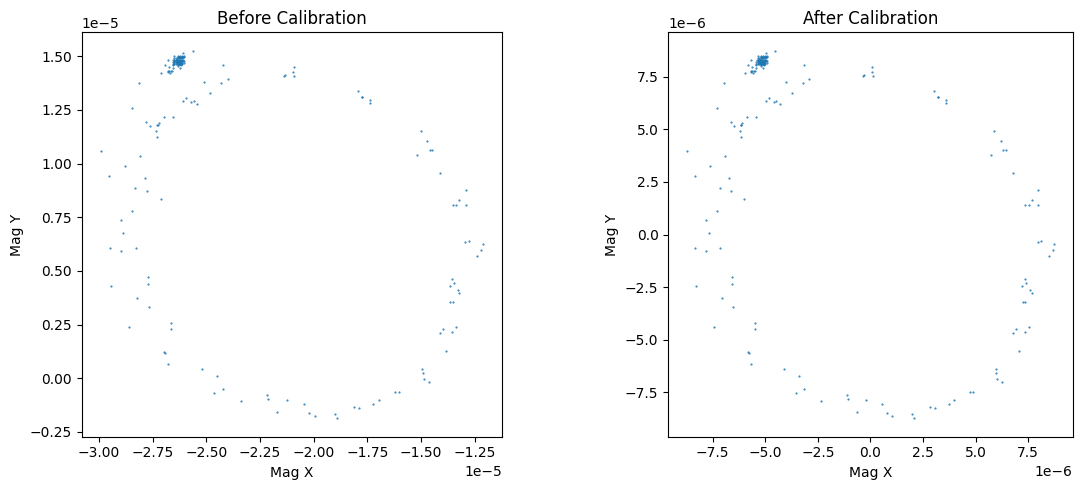

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# --- Fit an ellipse to the raw mag data ---
# The model: (x - x0)^2/a^2 + (y - y0)^2/b^2 = 1
# Hard iron offset = (x0, y0)
# Soft iron = scaling to make ellipse -> circle

mag_x = df_circle['mag_x'].values
mag_y = df_circle['mag_y'].values

# Hard iron correction: just subtract the center
x_offset = (mag_x.max() + mag_x.min()) / 2
y_offset = (mag_y.max() + mag_y.min()) / 2

mag_x_corrected = mag_x - x_offset
mag_y_corrected = mag_y - y_offset

# Soft iron correction: scale axes to equal radius
x_radius = (mag_x.max() - mag_x.min()) / 2
y_radius = (mag_y.max() - mag_y.min()) / 2
avg_radius = (x_radius + y_radius) / 2

scale_x = avg_radius / x_radius
scale_y = avg_radius / y_radius

mag_x_corrected *= scale_x
mag_y_corrected *= scale_y

# Plot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(mag_x, mag_y, '.', markersize=1)
axes[0].set_title('Before Calibration')
axes[0].set_aspect('equal')
axes[0].set_xlabel('Mag X'); axes[0].set_ylabel('Mag Y')

axes[1].plot(mag_x_corrected, mag_y_corrected, '.', markersize=1)
axes[1].set_title('After Calibration')
axes[1].set_aspect('equal')
axes[1].set_xlabel('Mag X'); axes[1].set_ylabel('Mag Y')
plt.tight_layout()
plt.show()

In [14]:
# Raw yaw (uncorrected)
yaw_mag_raw = np.degrees(np.arctan2(mag_y, mag_x))

# Corrected yaw (using calibrated values)
yaw_mag_corrected = np.degrees(np.arctan2(mag_y_corrected, mag_x_corrected))

# Now apply to the DRIVING data using the same calibration
drive_mag_x = (df_drive['mag_x'].values - x_offset) * scale_x
drive_mag_y = (df_drive['mag_y'].values - y_offset) * scale_y
yaw_mag = np.degrees(np.arctan2(drive_mag_y, drive_mag_x))

In [15]:
from scipy.integrate import cumulative_trapezoid

time = df_drive['timestamp'].values  # in seconds
gyro_z = df_drive['gyro_z'].values   # rad/s

# cumulative_trapezoid is Python's cumtrapz
yaw_gyro_rad = cumulative_trapezoid(gyro_z, time, initial=0)
yaw_gyro = np.degrees(yaw_gyro_rad)

In [16]:
from scipy.signal import butter, filtfilt

def lowpass(data, cutoff, fs, order=2):
    b, a = butter(order, cutoff / (fs / 2), btype='low')
    return filtfilt(b, a, data)

def highpass(data, cutoff, fs, order=2):
    b, a = butter(order, cutoff / (fs / 2), btype='high')
    return filtfilt(b, a, data)

# Determine your sampling frequency
dt = np.median(np.diff(time))
fs = 1.0 / dt

# Unwrap the magnetometer yaw first to avoid jumps
yaw_mag_unwrapped = np.unwrap(np.radians(yaw_mag))
yaw_mag_unwrapped = np.degrees(yaw_mag_unwrapped)

# Pick a cutoff frequency — start around 0.1 Hz, adjust based on your data
cutoff = 0.1  # Hz

yaw_mag_lp = lowpass(yaw_mag_unwrapped, cutoff, fs)
yaw_gyro_hp = highpass(yaw_gyro, cutoff, fs)

# Complementary filter = low-pass mag + high-pass gyro
yaw_complementary = yaw_mag_lp + yaw_gyro_hp

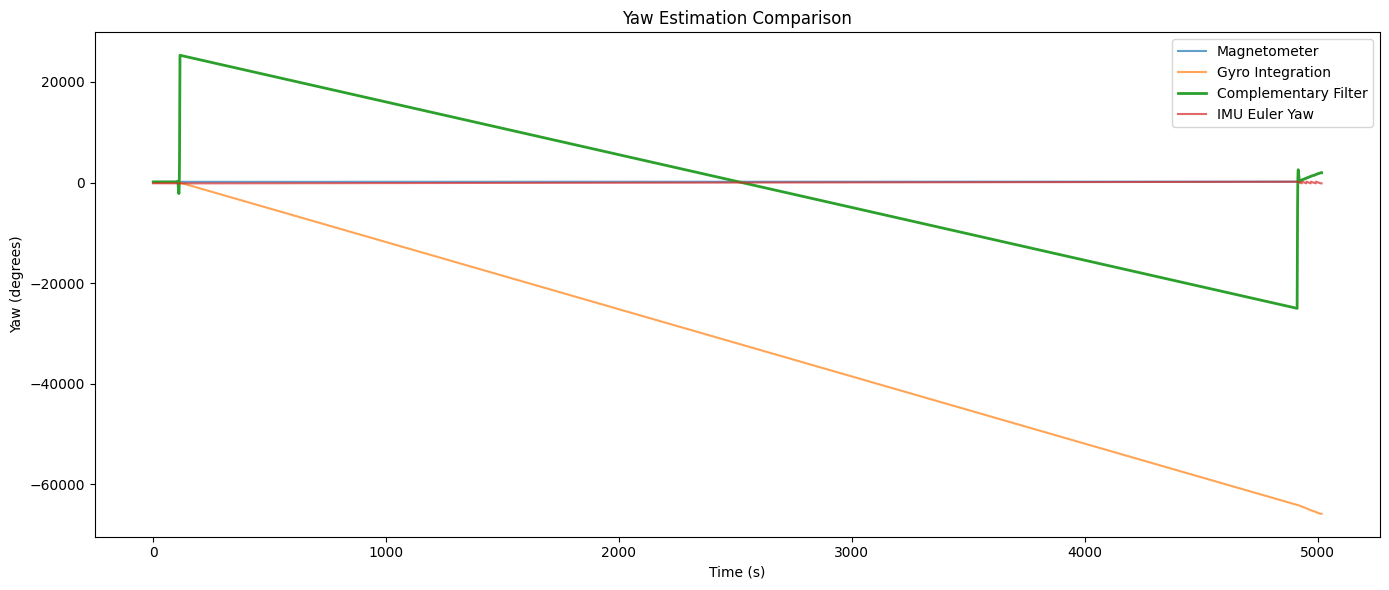

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(time, yaw_mag_unwrapped, label='Magnetometer', alpha=0.7)
ax.plot(time, yaw_gyro, label='Gyro Integration', alpha=0.7)
ax.plot(time, yaw_complementary, label='Complementary Filter', linewidth=2)
ax.plot(time, df_drive['imu_yaw'].values, label='IMU Euler Yaw', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Yaw (degrees)')
ax.set_title('Yaw Estimation Comparison')
ax.legend()
plt.tight_layout()
plt.show()